# Install Libraries

In [51]:
!pip install yfinance pandas numpy scipy matplotlib plotly

In [52]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize

In [53]:
assets = [
    "SPY",   # S&P 500
    "QQQ",   # Nasdaq
    "AGG",   # Bonds
    "GLD",   # Gold
    "VNQ"    # Real Estate
]

data = yf.download(
    assets,
    start="2019-01-01",
    end="2025-01-01",
    auto_adjust=True,
    threads=False
)["Close"]

print(data.head())

[*********************100%***********************]  5 of 5 completed

Ticker            AGG         GLD         QQQ         SPY        VNQ
Date                                                                
2019-01-02  86.043762  121.330002  147.878342  223.805939  55.523533
2019-01-03  86.398994  122.430000  143.047104  218.465286  55.911720
2019-01-04  86.140671  121.440002  149.167313  225.783005  56.566284
2019-01-07  85.995316  121.860001  150.943253  227.563171  57.121899
2019-01-08  85.930717  121.529999  152.308563  229.701248  58.301613


In [54]:
print(type(data))
print(data.shape)
print(data.columns)

<class 'pandas.core.frame.DataFrame'>
(1510, 5)
Index(['AGG', 'GLD', 'QQQ', 'SPY', 'VNQ'], dtype='object', name='Ticker')


In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1510 entries, 2019-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AGG     1510 non-null   float64
 1   GLD     1510 non-null   float64
 2   QQQ     1510 non-null   float64
 3   SPY     1510 non-null   float64
 4   VNQ     1510 non-null   float64
dtypes: float64(5)
memory usage: 70.8 KB


In [50]:
import numpy as np

weights = np.random.random(len(data.columns))
weights = weights / np.sum(weights)

print(weights)

[0.23721445 0.21752727 0.25631332 0.10900586 0.1799391 ]


In [56]:
returns = data.pct_change().dropna()

print(returns.head())

Ticker           AGG       GLD       QQQ       SPY       VNQ
Date                                                        
2019-01-03  0.004129  0.009066 -0.032670 -0.023863  0.006991
2019-01-04 -0.002990 -0.008086  0.042785  0.033496  0.011707
2019-01-07 -0.001687  0.003458  0.011906  0.007884  0.009822
2019-01-08 -0.000751 -0.002708  0.009045  0.009396  0.020653
2019-01-09  0.000846  0.006418  0.008150  0.004673 -0.001436


In [57]:
annual_returns = returns.mean() * 252

cov_matrix = returns.cov() * 252

print("Annual Returns")
print(annual_returns)

print("\nCovariance Matrix")
print(cov_matrix)

Annual Returns
Ticker
AGG    0.012592
GLD    0.126598
QQQ    0.235696
SPY    0.177744
VNQ    0.099461
dtype: float64

Covariance Matrix
Ticker       AGG       GLD       QQQ       SPY       VNQ
Ticker                                                  
AGG     0.004064  0.003595  0.002486  0.002003  0.004230
GLD     0.003595  0.022346  0.004886  0.003653  0.006275
QQQ     0.002486  0.004886  0.059202  0.044957  0.036437
SPY     0.002003  0.003653  0.044957  0.039347  0.036926
VNQ     0.004230  0.006275  0.036437  0.036926  0.056697


In [58]:
weights = np.random.random(len(assets))

weights /= np.sum(weights)

print("Weights")

for asset, weight in zip(assets, weights):
    print(asset, round(weight, 3))

Weights
SPY 0.052
QQQ 0.344
AGG 0.23
GLD 0.129
VNQ 0.246


In [59]:
portfolio_return = np.sum(weights * annual_returns)

portfolio_variance = np.dot(
    weights.T,
    np.dot(cov_matrix, weights)
)

portfolio_risk = np.sqrt(portfolio_variance)

sharpe_ratio = portfolio_return / portfolio_risk

print("Expected Return:", round(portfolio_return,4))
print("Risk:", round(portfolio_risk,4))
print("Sharpe:", round(sharpe_ratio,4))

Expected Return: 0.1457
Risk: 0.1464
Sharpe: 0.995


# Monte Carlo Simulation 

In [61]:
num_portfolios = 10000

results = np.zeros((3, num_portfolios))

weights_record = []

for i in range(num_portfolios):

    weights = np.random.random(len(assets))
    weights /= np.sum(weights)

    weights_record.append(weights)

    portfolio_return = np.sum(
        weights * annual_returns
    )

    portfolio_risk = np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

    sharpe = portfolio_return / portfolio_risk

    results[0, i] = portfolio_return
    results[1, i] = portfolio_risk
    results[2, i] = sharpe

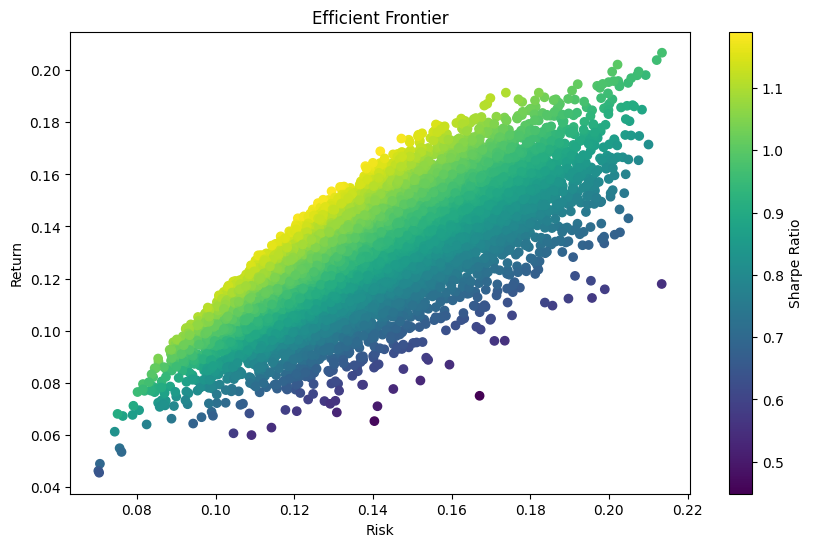

In [62]:
plt.figure(figsize=(10,6))

plt.scatter(
    results[1,:],
    results[0,:],
    c=results[2,:]
)

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Efficient Frontier")

plt.colorbar(label="Sharpe Ratio")

plt.show()

In [63]:
max_sharpe_idx = np.argmax(results[2])

best_return = results[0,max_sharpe_idx]
best_risk = results[1,max_sharpe_idx]
best_weights = weights_record[max_sharpe_idx]

print("Optimal Portfolio")
print("------------------")

for asset, weight in zip(assets, best_weights):
    print(asset, round(weight*100,2), "%")

print("\nReturn:", round(best_return,4))
print("Risk:", round(best_risk,4))
print("Sharpe:", round(best_return/best_risk,4))

Optimal Portfolio
------------------
SPY 0.36 %
QQQ 49.6 %
AGG 31.37 %
GLD 17.29 %
VNQ 1.38 %

Return: 0.1689
Risk: 0.1419
Sharpe: 1.1902


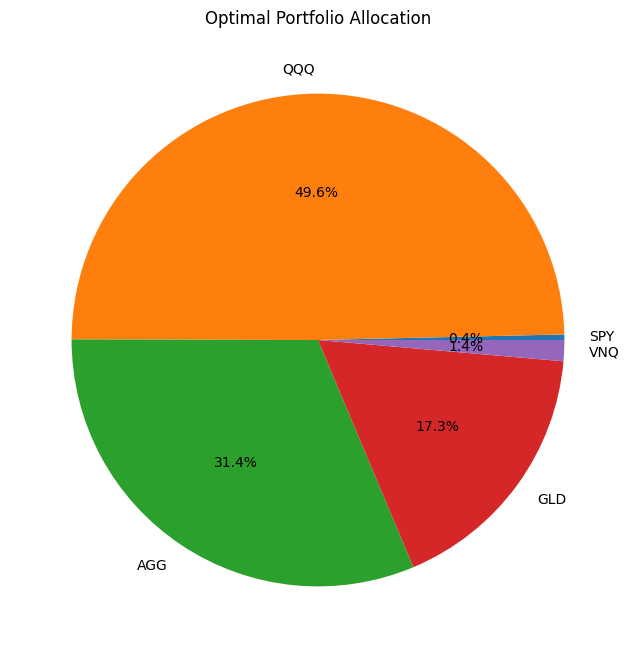

In [64]:
plt.figure(figsize=(8,8))

plt.pie(
    best_weights,
    labels=assets,
    autopct="%1.1f%%"
)

plt.title("Optimal Portfolio Allocation")

plt.show()

# Value at Risk (VaR)

In [65]:
portfolio_daily_returns = returns.dot(best_weights)

var_95 = np.percentile(
    portfolio_daily_returns,
    5
)

print("95% Daily VaR:", round(var_95*100,2), "%")

95% Daily VaR: -1.32 %


# Growth Protection

In [66]:
investment = 10000

future_value = investment * (
    1 + best_return
) ** 10

print(
    "Projected 10-Year Value: $",
    round(future_value,2)
)

Projected 10-Year Value: $ 47609.48
